## Lab 7: Ensemble Methods for Forest Cover Classification

**Dataset:** UCI Forest Cover Type (id=31) (the same dataset from Lab 6)

In Lab 6, you found that a single decision tree can achieve strong performance on forest cover classification but tends to overfit. In this lab you will apply three **ensemble methods** that address this problem in different ways:

| Method | Strategy |
|--------|----------|
| **Bagging** | Average many trees trained on bootstrap samples | 
| **Random Forest** | Bagging + random feature subsets at each split | 
| **Gradient Boosting** | Build trees sequentially, each correcting the previous |


### Step 1: Load and Explore the Data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [18]:
forest = fetch_ucirepo(id=31)

df = pd.concat([forest.data.features, forest.data.targets], axis=1)

print(f"Full dataset shape: {df.shape}")
print()
print("Cover type distribution (full dataset):")
print(df['Cover_Type'].value_counts().sort_index())
df.head()

Full dataset shape: (581012, 55)

Cover type distribution (full dataset):
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


### Step 2: Repeat preprocessing steps from Lab 6


In [19]:
df_sample = df.sample(n=30_000, random_state=42)

features = [c for c in df_sample.columns if c != 'Cover_Type']
X = df_sample[features]
y = df_sample['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(f"Training samples: {len(X_train):,}  |  Test samples: {len(X_test):,}")

Training samples: 20,100  |  Test samples: 9,900


### Step 3: Decision Tree Baseline

Repeate the untuned decision tree we fit as a baselin in Lab 6. Recall that a fully grown tree achieves near-perfect training accuracy but lower test accuracy due to overfitting.

In [20]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_test_acc  = accuracy_score(y_test,  dt.predict(X_test))

print(f"Decision Tree depth:          {dt.get_depth()}")
print(f"Decision Tree training acc:   {dt_train_acc:.3f}")
print(f"Decision Tree test acc:       {dt_test_acc:.3f}")

Decision Tree depth:          35
Decision Tree training acc:   1.000
Decision Tree test acc:       0.770


> **Recall from Lab 6:** The gap between training and test accuracy is a clear sign of overfitting. A fully-grown tree memorizes the training set. Ensemble methods are designed to close this gap.

---
## Background: Bagging



### Step 4: Fit a Bagging Classifier

Fit a `BaggingClassifier` with `n_estimators=50` and `oob_score=True`. The out-of-bag (OOB) score is a free estimate of test accuracy computed from the bootstrap samples left out of each tree. Compare OOB score, training accuracy, and test accuracy to the single decision tree.

In [21]:
bag = BaggingClassifier(n_estimators=50, oob_score=True, random_state=42, n_jobs=-1)
bag.fit(X_train, y_train)

bag_train_acc = accuracy_score(y_train, bag.predict(X_train))
bag_test_acc  = accuracy_score(y_test,  bag.predict(X_test))

print(f"Decision Tree training acc:   {dt_train_acc:.3f}")
print(f"Decision Tree test acc:       {dt_test_acc:.3f}")
print()
print(f"Bagging OOB score:            {bag.oob_score_:.3f}")
print(f"Bagging training acc:         {bag_train_acc:.3f}")
print(f"Bagging test acc:             {bag_test_acc:.3f}")

Decision Tree training acc:   1.000
Decision Tree test acc:       0.770

Bagging OOB score:            0.838
Bagging training acc:         1.000
Bagging test acc:             0.840


>  How does the OOB score compare to test accuracy? How did bagging change the gap between training and test accuracy relative to the single decision tree?

### Step 5: Tune the Number of Trees for Bagging

More trees in a bagging model generally improve performance up to a point, after which the gains plateau (unlike boosting, adding trees in bagging never hurts but it does add compute time). Use **5-fold cross-validation** on the training set to evaluate `n_estimators` values of 10, 25, 50, 100, and 200. Plot CV accuracy vs. number of trees.

Best n_estimators: 100  (CV accuracy: 0.839)


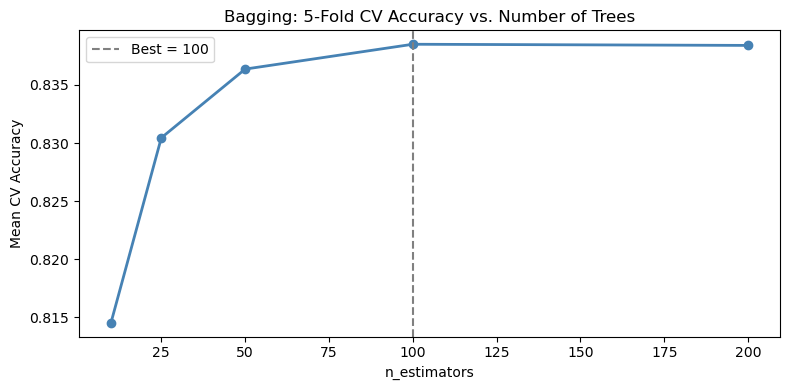

In [22]:
n_estimators_range = [10, 25, 50, 100, 200]
bag_cv_accs = []

for n in n_estimators_range:
    bag_cv = BaggingClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    scores  = cross_val_score(bag_cv, X_train, y_train, cv=5, scoring='accuracy')
    bag_cv_accs.append(scores.mean())

best_n_bag = n_estimators_range[np.argmax(bag_cv_accs)]
print(f"Best n_estimators: {best_n_bag}  (CV accuracy: {max(bag_cv_accs):.3f})")

plt.figure(figsize=(8, 4))
plt.plot(n_estimators_range, bag_cv_accs, marker='o', color='steelblue', linewidth=2)
plt.axvline(best_n_bag, color='gray', linestyle='--', label=f'Best = {best_n_bag}')
plt.xlabel('n_estimators')
plt.ylabel('Mean CV Accuracy')
plt.title('Bagging: 5-Fold CV Accuracy vs. Number of Trees')
plt.legend()
plt.tight_layout()
plt.show()

> At what point do additional trees stop providing meaningful improvement? How does this differ from what you would expect with decision trees, where not specifying a `max_depth` can cause overfitting?

---
## Background: Random Forests



### Step 6: Fit a Random Forest

Fit a `RandomForestClassifier` using the best `n_estimators` found in Step 5 and the default `max_features='sqrt'`. Enable `oob_score=True`. Compare test accuracy and OOB score to bagging and the single tree.

In [23]:
rf = RandomForestClassifier(
    n_estimators=best_n_bag, oob_score=True, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc  = accuracy_score(y_test,  rf.predict(X_test))

print(f"Decision Tree test acc:   {dt_test_acc:.3f}")
print(f"Bagging test acc:         {bag_test_acc:.3f}")
print()
print(f"Random Forest OOB score:  {rf.oob_score_:.3f}")
print(f"Random Forest test acc:   {rf_test_acc:.3f}")

Decision Tree test acc:   0.770
Bagging test acc:         0.840

Random Forest OOB score:  0.838
Random Forest test acc:   0.837


> Did random forests outperform bagging? This dataset has 54 features, 44 of which are binary soil-type indicators. How might the structure of the feature space affect whether random feature subsets help?

### Step 7: Tune the Random Forest with GridSearchCV

Tuning `max_features` alone ignores interactions with tree depth. Use `GridSearchCV` to jointly search over:

- `n_estimators`: [50, 100]
- `max_features`: [`'sqrt'`, `'log2'`, 0.3]
- `max_depth`: [10, 20, `None`]

Use `cv=3` to keep runtimes manageable. Print the best parameters and evaluate the best estimator on the test set.

In [24]:
param_grid = {
    'n_estimators': [50, 100],
    'max_features': ['sqrt', 'log2', 0.3],
    'max_depth':    [10, 20, None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

rf_best      = rf_grid.best_estimator_
rf_best_acc  = accuracy_score(y_test, rf_best.predict(X_test))

print(f"Best parameters:  {rf_grid.best_params_}")
print(f"Test accuracy:    {rf_best_acc:.3f}")

Best parameters:  {'max_depth': None, 'max_features': 0.3, 'n_estimators': 100}
Test accuracy:    0.844


> **Discussion Questions**
> 1. Did joint tuning change the best `max_features` value compared to the default `'sqrt'`? Why might searching parameters jointly produce a different answer than tuning them one at a time?
> 2. What does the best `max_depth` tell you? If `None` (fully-grown trees) wins, what does that suggest about where the benefit of random forests comes from on this dataset?

---
## Background: Gradient Boosting

Bagging and random forests build trees **in parallel** — each tree is independent and the predictions are averaged. **Gradient boosting** takes the opposite approach. Trees are built **sequentially**, with each new tree trained to correct the residual errors of all the trees before it.


- Bagging/RF primarily reduce **variance** because it smooths out the predictions of a single deep tree.

- Boosting primarily reduces **bias** because it iteratively improves a model that is initially underfitting.

Because each tree depends on the previous ones, adding too many trees causes **overfitting**. We use **early stopping** to find the optimal number of trees.

### Step 8: XGBoost with Early Stopping

XGBoost requires a hold-out validation set for early stopping. Split 20% off the training data for this purpose. Then initialize `XGBClassifier` with `n_estimators=500`, `learning_rate=0.1`, and `early_stopping_rounds=20`. Fit with `eval_set=[(X_val, y_val)]` and `verbose=False`. After fitting, print the optimal number of trees and test accuracy.

**Note**: XGBoost requires 0-indexed labels. Cover_Type is labeled as 1–7 so we need to shift to 0–6.

In [27]:
# Make Cover_Type 0 indexed
y_train_0 = y_train - 1
y_test_0  = y_test  - 1

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train_0, test_size=0.2, random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

best_n_trees = xgb_model.best_iteration + 1
xgb_test_acc = accuracy_score(y_test_0, xgb_model.predict(X_test))

print(f"Optimal number of trees: {best_n_trees}")
print(f"XGBoost test accuracy:   {xgb_test_acc:.3f}")

Optimal number of trees: 454
XGBoost test accuracy:   0.825


> How does XGBoost's test accuracy compare to the random forest? How many trees did early stopping select. Is this more or fewer than the bagging models? Why might boosting need fewer trees to achieve comparable or better performance?

### Step 9: Model Comparison

Collect the test accuracy for all four models and plot them together. Then visualize the top 15 most important features from the tuned random forest and XGBoost side by side.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


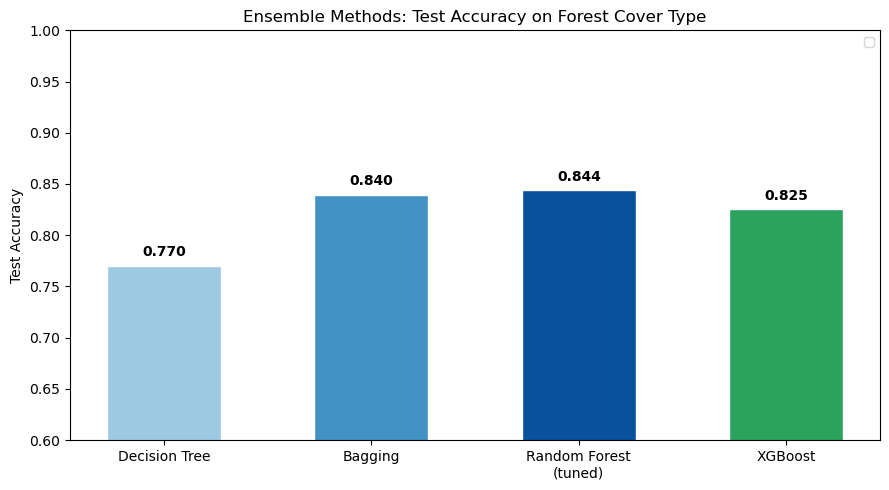

In [29]:
model_names = ['Decision Tree', 'Bagging', 'Random Forest\n(tuned)', 'XGBoost']
test_accs   = [dt_test_acc, bag_test_acc, rf_best_acc, xgb_test_acc]
colors      = ['#9ecae1', '#4292c6', '#08519c', '#2ca25f']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, test_accs, color=colors, edgecolor='white', width=0.55)
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('Test Accuracy')
ax.set_title('Ensemble Methods: Test Accuracy on Forest Cover Type')
ax.legend(fontsize=9)

for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.006,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

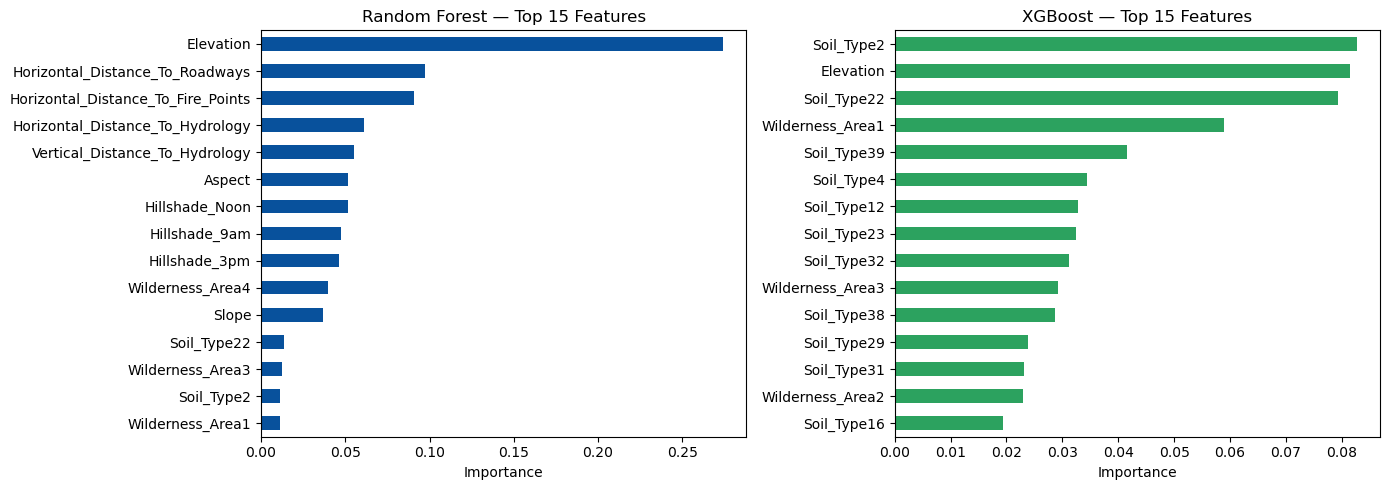

In [30]:
rf_imp  = pd.Series(rf_best.feature_importances_,  index=features)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_imp.nlargest(15).sort_values().plot(
    kind='barh', ax=axes[0], color='#08519c'
)
axes[0].set_title('Random Forest — Top 15 Features')
axes[0].set_xlabel('Importance')

xgb_imp.nlargest(15).sort_values().plot(
    kind='barh', ax=axes[1], color='#2ca25f'
)
axes[1].set_title('XGBoost — Top 15 Features')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

> **Discussion Questions**
> 1. Which ensemble method performed best on this dataset? Does the ranking surprise you given the bias-variance framing in the background sections?
> 2. Do the random forest and XGBoost feature importance rankings agree on the top features? If they differ, why might two models trained on the same data weight features differently?
> 3. This dataset has 44 binary soil-type indicators. How do both models handle these features — do many of them appear in the top 15, or does a small number of continuous features dominate?

*Your answers here*